In [ ]:
# standard
import sys

# specific
import pandas as pd

# torch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchinfo
from torch.utils import data as torch_data
from torchmetrics import Accuracy

import lightning as L

# quantum
from qiskit.circuit.library import real_amplitudes

sys.modules.pop('geqie_qml', None)  # force reload of geqie_qml module
import geqie_qml


In [2]:
# plotting
import plotly.express as px
import plotly.io as pio
import plotly.graph_objects as go

from plotly.subplots import make_subplots

pio.templates["latex"] = pio.templates["plotly_white"].update(
    layout=dict(
        colorway=px.colors.qualitative.D3,
        font=dict(
            family="CMU Serif",
            # size=24
        )
    )
)

pio.templates.default = "latex"


## Dataset definition

In [3]:
DATASET_SAMPLE_SIZE = 1000 # or None for full dataset

VAL_SPLIT = 0.2
NUM_TRAINING_WORKERS = 0    # os.cpu_count() - 1 
NUM_VALIDATION_WORKERS = 0  # 0 means just the main process

BATCH_SIZE = 32


In [ ]:
train_ds, test_ds = geqie_qml.load_precomputed_zip_matrices("../.precomputed_8x8.zip")
FULL_TRAIN_DATASET_SIZE = len(train_ds)

effective_size = DATASET_SAMPLE_SIZE or FULL_TRAIN_DATASET_SIZE
n_val   = int(effective_size * VAL_SPLIT)
n_train = effective_size - n_val
train_subset, val_subset, _ = torch_data.random_split(
    train_ds,
    [n_train, n_val, FULL_TRAIN_DATASET_SIZE - effective_size],
    generator=torch.Generator().manual_seed(42),
)

train_loader = torch_data.DataLoader(
    train_subset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=NUM_TRAINING_WORKERS,
    persistent_workers=(NUM_TRAINING_WORKERS > 0),
)
val_loader = torch_data.DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_VALIDATION_WORKERS,
    persistent_workers=(NUM_VALIDATION_WORKERS > 0),
)
test_loader = torch_data.DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    num_workers=NUM_VALIDATION_WORKERS,
)

print(f"Train: {n_train}, Val: {n_val}, Test: {len(test_ds)}")


Train: 800, Val: 200, Test: 10000


## Model definition

In [5]:
N_QUBITS = 7
N_CLASSES = 10
N_LAYERS = 4

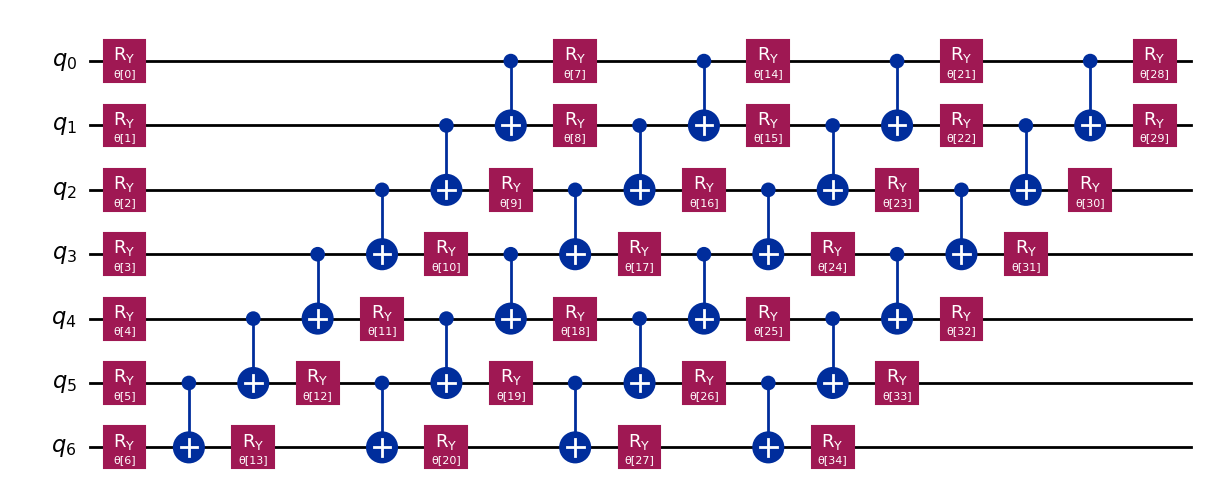

In [6]:
test_ansatz = real_amplitudes(N_QUBITS, reps=N_LAYERS)
test_ansatz.draw("mpl")


In [7]:
geqie_layer  = geqie_qml.PrecomputedInputLayer(N_QUBITS)
ansatz_layer = geqie_qml.AnsatzLayer(N_QUBITS, test_ansatz)
print(geqie_layer)
print(ansatz_layer)


PrecomputedInputLayer(num_qubits=7, dim=128)
AnsatzLayer(num_qubits=7, dim=128, weights=35, param_gates=35, fixed_gates=24)


In [8]:
model = nn.Sequential(
    geqie_qml.PrecomputedInputLayer(N_QUBITS),    # (B, dim, dim) → (B, dim) complex
    geqie_qml.AnsatzLayer(N_QUBITS, test_ansatz), # (B, dim) → (B, dim) probs
    nn.Linear(2**N_QUBITS, N_CLASSES),
    nn.LogSoftmax(dim=-1),
)


In [9]:
torchinfo.summary(model)

Layer (type:depth-idx)                   Param #
Sequential                               --
├─PrecomputedInputLayer: 1-1             --
├─AnsatzLayer: 1-2                       35
├─Linear: 1-3                            1,290
├─LogSoftmax: 1-4                        --
Total params: 1,325
Trainable params: 1,325
Non-trainable params: 0

## Training with Lightning

In [10]:
class VQCModule(L.LightningModule):
    """
    Lightning wrapper around the GEQIE VQC model.

    The model is expected to end with ``nn.LogSoftmax``, so
    ``F.nll_loss`` is used as the loss function.
    """

    def __init__(self, model: nn.Module, n_classes: int, lr: float = 1e-3):
        super().__init__()
        self.save_hyperparameters(ignore=["model"])
        self.model = model
        self.train_acc = Accuracy(task="multiclass", num_classes=n_classes)
        self.val_acc   = Accuracy(task="multiclass", num_classes=n_classes)

    def forward(self, x):
        return self.model(x)

    def _shared_step(self, batch):
        x, y = batch
        log_probs = self(x)
        loss = F.nll_loss(log_probs, y)
        preds = log_probs.argmax(dim=-1)
        return loss, preds, y

    def training_step(self, batch, batch_idx):
        loss, preds, y = self._shared_step(batch)
        self.train_acc(preds, y)
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc",  self.train_acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        loss, preds, y = self._shared_step(batch)
        self.val_acc(preds, y)
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        self.log("val_acc",  self.val_acc, on_epoch=True, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)


In [11]:
vqc_module = VQCModule(model, n_classes=N_CLASSES, lr=0.1)

trainer = L.Trainer(
    max_epochs=50,
    accelerator="auto",
    log_every_n_steps=1,
    enable_progress_bar=True,
    callbacks=[L.pytorch.callbacks.TQDMProgressBar(leave=True)],

    ### speedup params
    # fast_dev_run=True,
    # limit_train_batches=100,
    # limit_val_batches=10,
    # limit_test_batches=10,
    num_sanity_val_steps=0,
)

trainer.fit(
    vqc_module,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader,
)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
d:\git\merQlab\geqie\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatica

Training: |          | 0/? [00:00<?, ?it/s]
Epoch 49: 100%|██████████| 25/25 [00:04<00:00,  5.27it/s, v_num=36, val_loss=0.788, val_acc=0.755, train_loss=0.466, train_acc=0.873]

`Trainer.fit` stopped: `max_epochs=50` reached.


In [12]:
metrics = pd.read_csv(f"{trainer.logger.log_dir}/metrics.csv")

TRAIN_COLOR = "#1f77b4"  # matplotlib blue
VAL_COLOR   = "#ff7f0e"  # matplotlib orange

fig = make_subplots(rows=1, cols=2, subplot_titles=("Loss", "Accuracy"))

for cols, col_idx in [
    (["train_loss", "val_loss"], 1),
    (["train_acc",  "val_acc"],  2),
]:
    for c in cols:
        color = TRAIN_COLOR if c.startswith("train") else VAL_COLOR
        subset = metrics.dropna(subset=[c])
        fig.add_trace(
            go.Scatter(x=subset["epoch"], y=subset[c], mode="lines+markers", name=c,
                       line=dict(color=color), marker=dict(color=color)),
            row=1, col=col_idx,
        )

fig.update_xaxes(title_text="Epoch")
fig.update_layout(height=400, width=900)
fig.show()
